## Airport delay Heatmap Analysis (Year x Month x Day)

### 1. Create the basic heatmap structure as a foundation for further airport analysis (example: Munich Airport)

In [2]:
# Imports & connections

import os
import calplot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sqlalchemy import create_engine
from dotenv import load_dotenv

import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

load_dotenv()
DB_URL = os.getenv('DATABASE_URL')
engine = create_engine(DB_URL)

In [10]:
# -----------------------------------------------------------------
# 1. Prepare Data
# -----------------------------------------------------------------


dates_start = "2016-01-01"
dates_end = "2025-12-31"
apt_icao = 'LTFJ'

query_heatmap = """
SELECT
    flt_date,
    ROUND(SUM(COALESCE(dly_apt_arr_1, 0)) / NULLIF(SUM(flt_arr_1), 0), 2) AS avg_delay_per_arrival
FROM fact_airport_delay
WHERE flt_date >= %s AND flt_date <= %s AND apt_icao = %s
GROUP BY flt_date
ORDER BY flt_date ASC;
"""

ts_df = pd.read_sql(query_heatmap, engine, params=(dates_start, dates_end, apt_icao))

ts = ts_df.set_index("flt_date")["avg_delay_per_arrival"]

ts.index = pd.to_datetime(ts.index)

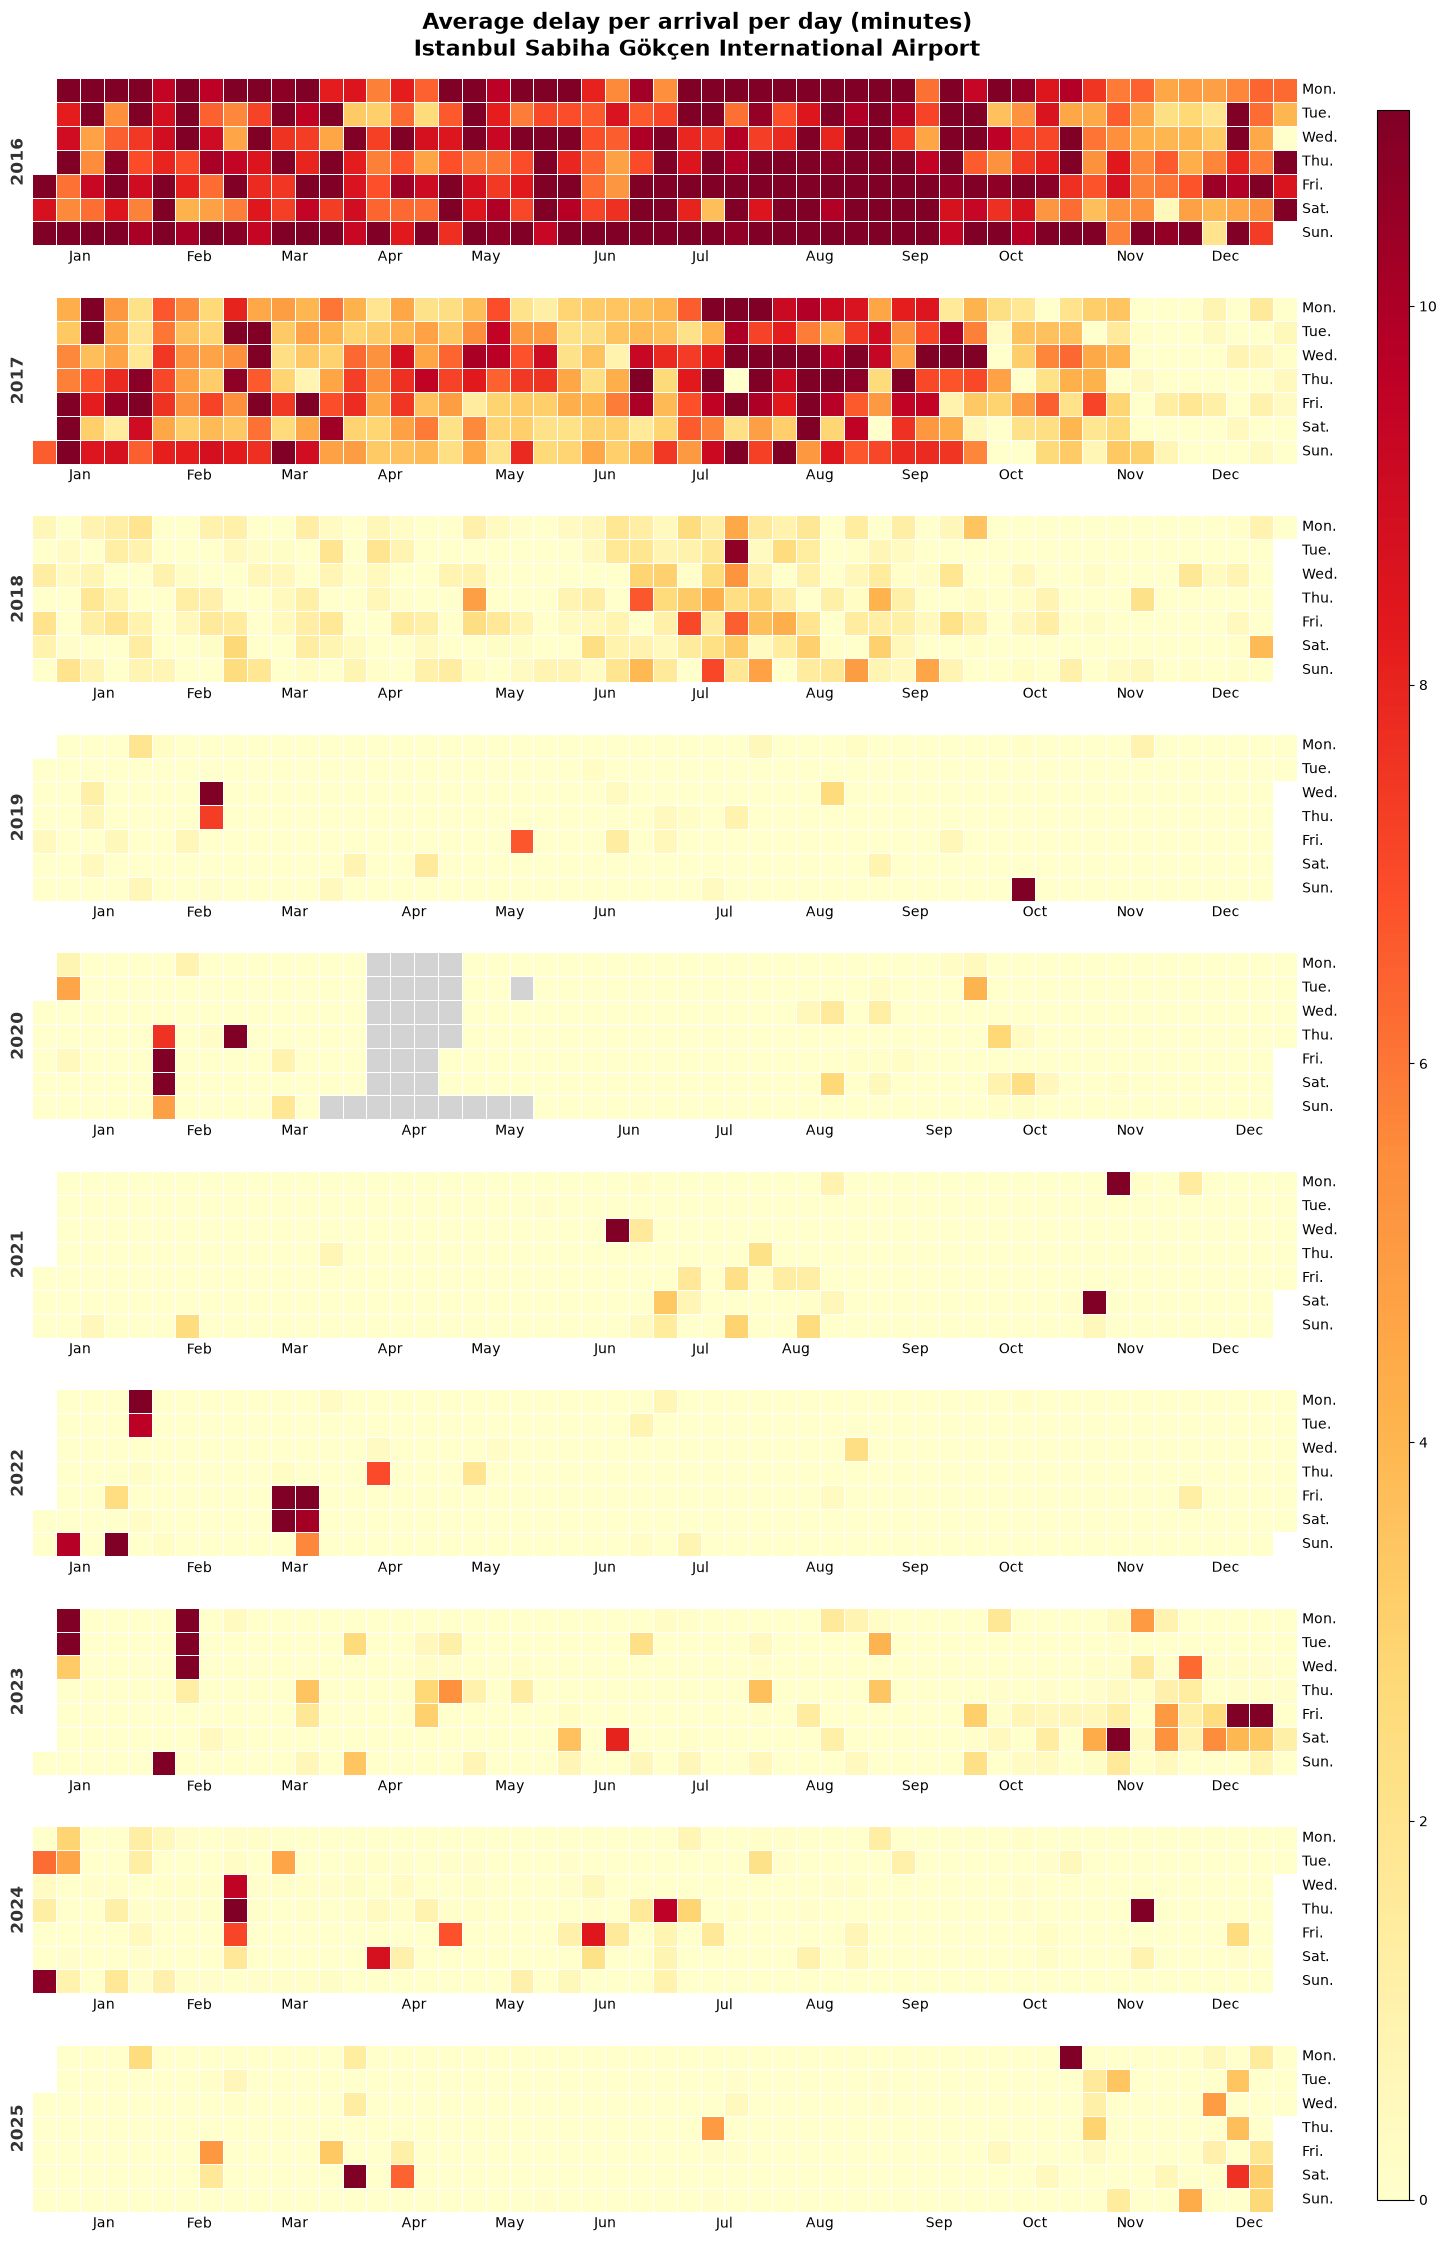

In [11]:
# -----------------------------------------------------------------
# 2. Heatmap
# -----------------------------------------------------------------

# Get airport name
query_name = """
SELECT name
FROM dim_airport
WHERE ident = %s;
"""
result = pd.read_sql(query_name, engine, params=(apt_icao,))

result['name'] = result['name'].apply(
    lambda x: x.encode('latin-1').decode('utf-8') if isinstance(x, str) else x
)

airport_name = result["name"].iloc[0]

# calculate figure height and title offset (dynamic)
n_years = ts.index.year.nunique()
fig_height = 2.2 * n_years
title_offset_inches = 0.45
title_y = 1 + (title_offset_inches / fig_height)

# vmax only over days with actual delay (excludes 0-values from scale calculation)
# to avoid skewing the colormap when most days have 0 ATFM delay (e.g. EDDM ~82%)
vmax = ts[ts > 0].quantile(0.85)

# Plot Heatmap
fig, axes = calplot.calplot(
    ts,
    how=None,                 # data is already aggregated daily, no resampling needed
    dropzero=False,           # prevent calplot from auto-converting 0→NaN when >50% zeros
    cmap="YlOrRd",
    colorbar=True,
    suptitle=f"Average delay per arrival per day (minutes)\n{airport_name}\n",
    suptitle_kws={"fontsize": 16, "fontweight": "bold", "y": title_y},
    figsize=(16, fig_height),
    edgecolor="white",
    linewidth=0.6,
    fillcolor="lightgrey",    # lightgrey = missing data (no row in fact_airport_delay)
    vmin=0,
    vmax=vmax,
    yearlabel_kws={"fontsize": 12, "fontweight": "bold", "color": "#333333"},
    monthlabels=["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                  "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    daylabels=["Mon.", "Tue.", "Wed.", "Thu.", "Fri.", "Sat.", "Sun."],
)

plt.show()

### 2. Identifcation of interesting Heatmaps

In [15]:
query_candidates = """
SELECT 
    fad.apt_icao,
    da.name AS apt_name,
    COUNT(fad.flt_date) AS days_with_data,
    ROUND(AVG(COALESCE(fad.dly_apt_arr_1, 0) / NULLIF(fad.flt_arr_1, 0))::numeric, 3) AS avg_delay,
    ROUND(MAX(COALESCE(fad.dly_apt_arr_1, 0) / NULLIF(fad.flt_arr_1, 0))::numeric, 2) AS max_delay,
    ROUND(STDDEV(COALESCE(fad.dly_apt_arr_1, 0) / NULLIF(fad.flt_arr_1, 0))::numeric, 3) AS stddev_delay,
    SUM(fad.flt_arr_1) AS total_arrivals
FROM fact_airport_delay fad
JOIN dim_airport da ON da.ident = fad.apt_icao
WHERE fad.flt_date >= '2018-01-01' 
  AND fad.flt_date < '2025-12-31'
GROUP BY fad.apt_icao, da.name
HAVING 
    COUNT(fad.flt_date) > 500
    AND SUM(fad.flt_arr_1) > 300000
    AND MAX(COALESCE(fad.dly_apt_arr_1, 0) / NULLIF(fad.flt_arr_1, 0)) < 100
ORDER BY stddev_delay DESC
LIMIT 20;
"""

df_candidates = pd.read_sql(query_candidates, engine)

df_candidates['apt_name'] = df_candidates['apt_name'].apply(lambda x: x.encode('latin-1').decode('utf-8') if isinstance(x, str) else x)

print(df_candidates.head(20))

   apt_icao                                           apt_name  \
0      LPPR                   Francisco de Sá Carneiro Airport   
1      EHAM                         Amsterdam Airport Schiphol   
2      EGKK                             London Gatwick Airport   
3      LPPT                    Lisbon Humberto Delgado Airport   
4      LEPA                          Palma de Mallorca Airport   
5      LGAV  Athens Eleftherios Venizelos International Air...   
6      LFPO                                 Paris-Orly Airport   
7      LEBL        Josep Tarradellas Barcelona-El Prat Airport   
8      EGLL                            London Heathrow Airport   
9      GCLP                               Gran Canaria Airport   
10     LLBG                   Ben Gurion International Airport   
11     LTFJ       Istanbul Sabiha Gökçen International Airport   
12     LFMN                           Nice-Côte d'Azur Airport   
13     EGSS                            London Stansted Airport   
14     EKC

**Result:** EHAM (Amsterdam Schiphol) and EGLL (London Heathrow)
Rationale:
- Both are top-5 European hubs (very high `total_arrivals`)
- EHAM has a significantly higher `avg_delay` (2.7) and `stddev` (5.3) than EGLL (1.5 / 3.2) despite similar size

### 3. Airport Heatmap Analysis for EHAM and EGLL

#### 3.1 EHAM (Amsterdam Schiphol)

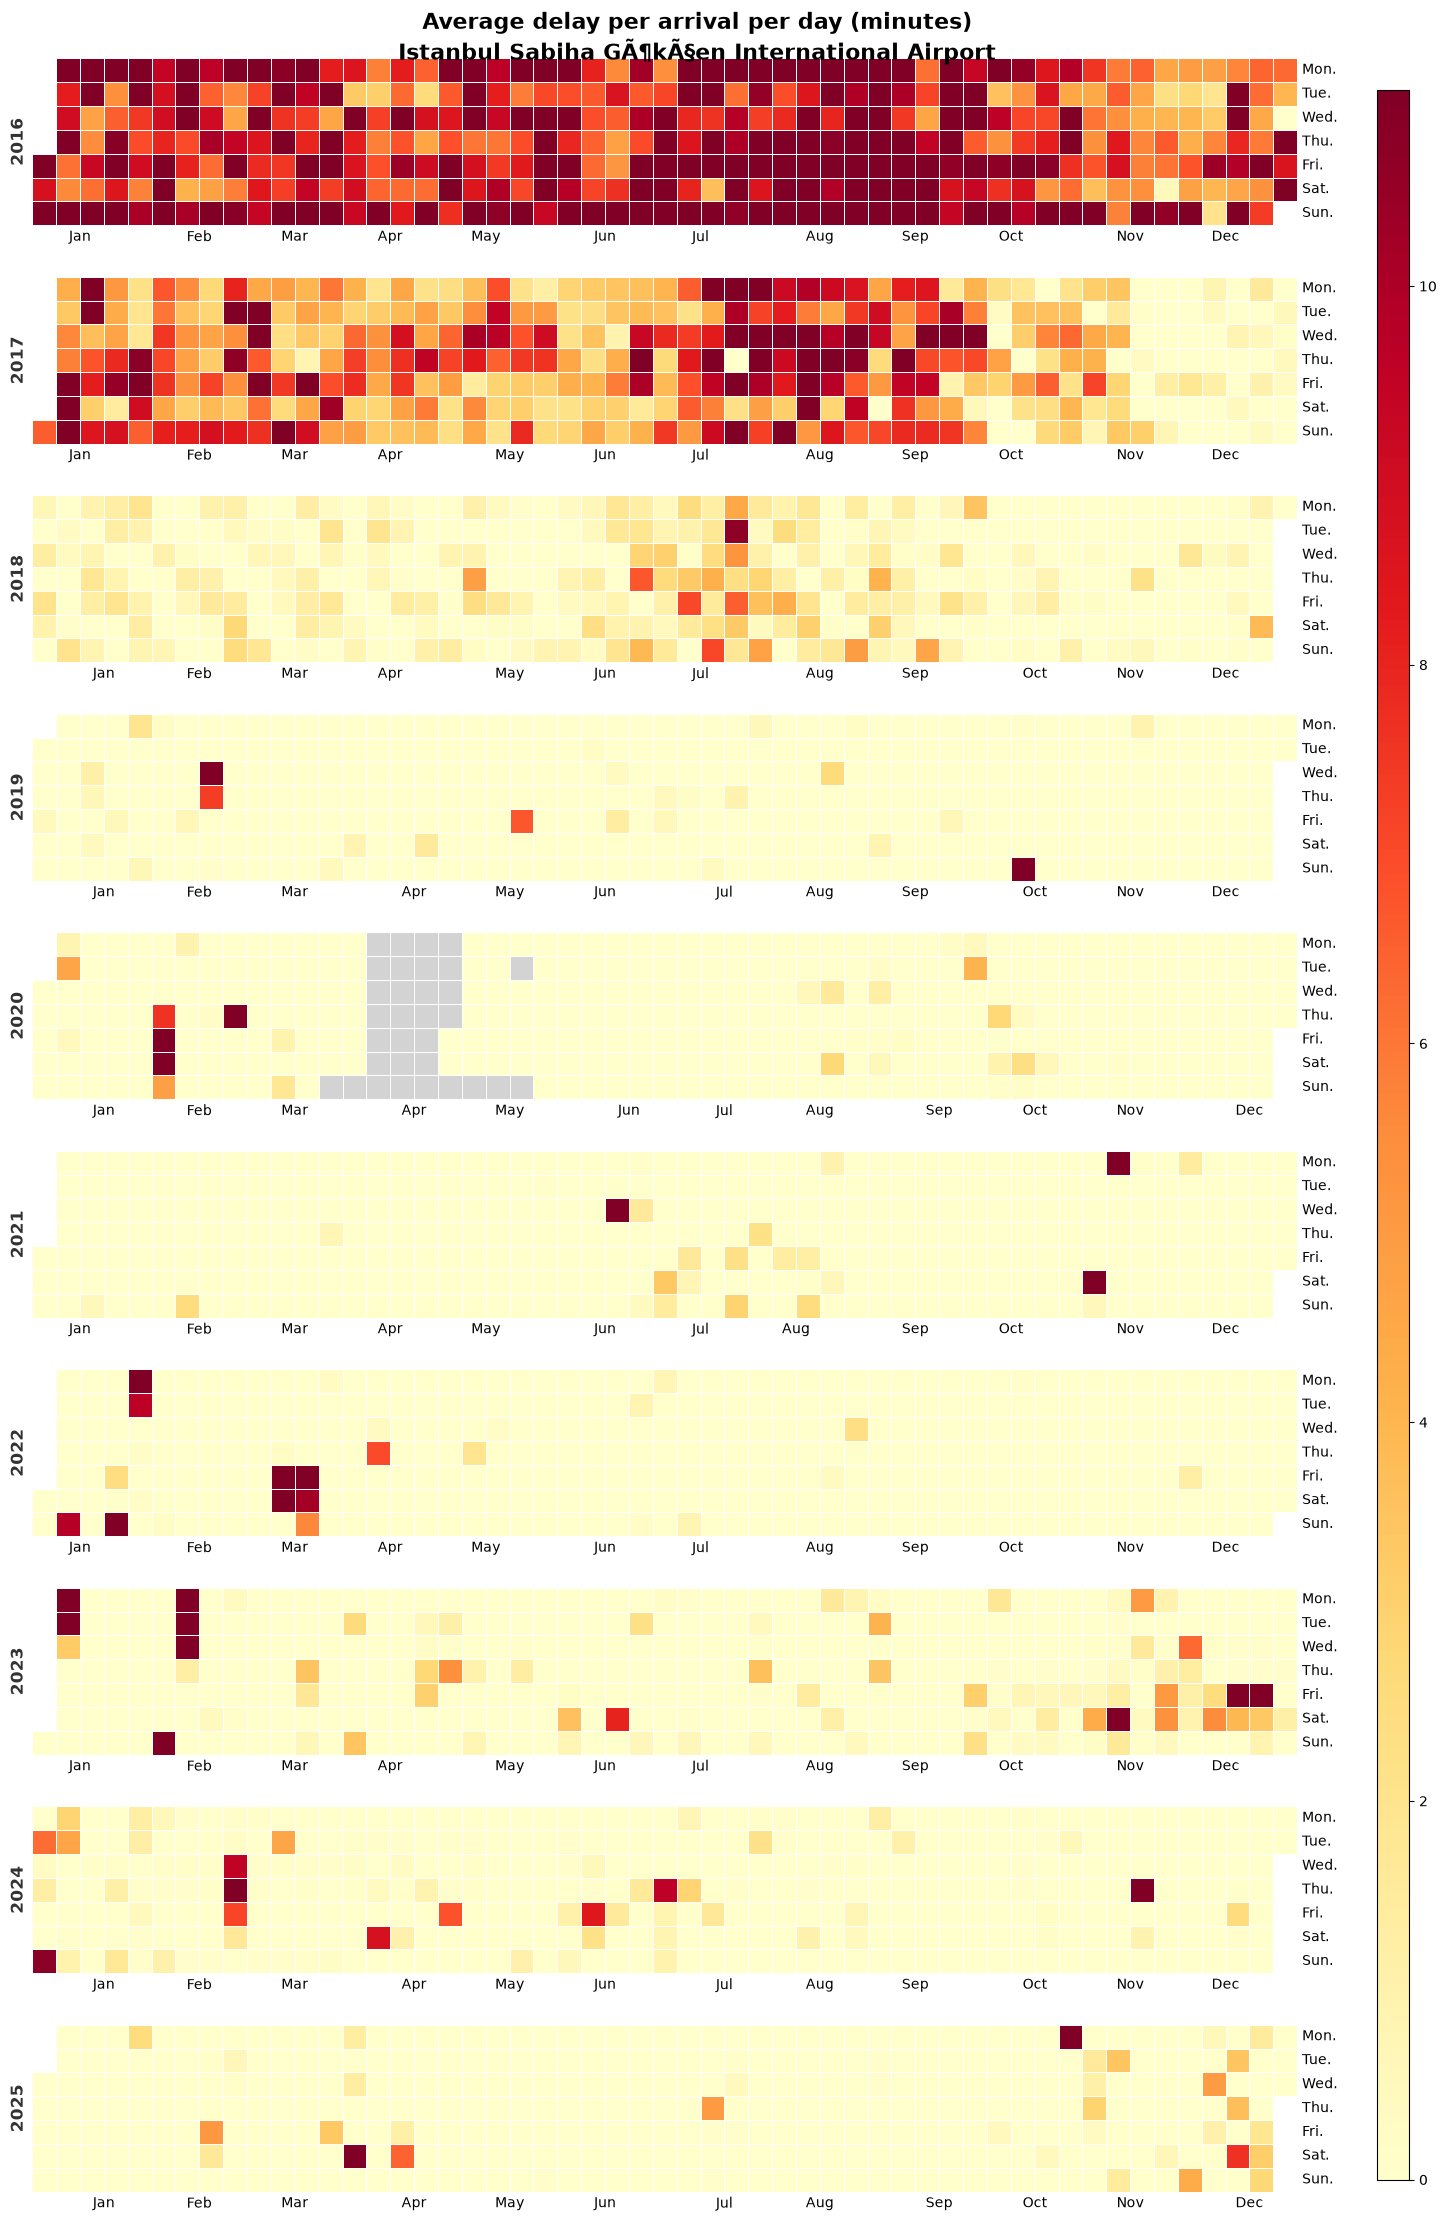

In [ ]:
# -----------------------------------------------------------------
# 1. Prepare Data
# -----------------------------------------------------------------


dates_start = "2016-01-01"
dates_end = "2025-12-31"
apt_icao = 'LTFJ'

query_heatmap = """
SELECT
    flt_date,
    ROUND(SUM(COALESCE(dly_apt_arr_1, 0)) / NULLIF(SUM(flt_arr_1), 0), 2) AS avg_delay_per_arrival
FROM fact_airport_delay
WHERE flt_date >= %s AND flt_date <= %s AND apt_icao = %s
GROUP BY flt_date
ORDER BY flt_date ASC;
"""

ts_df = pd.read_sql(query_heatmap, engine, params=(dates_start, dates_end, apt_icao))
ts = ts_df.set_index("flt_date")["avg_delay_per_arrival"]
ts.index = pd.to_datetime(ts.index)


# -----------------------------------------------------------------
# 2. Heatmap
# -----------------------------------------------------------------

# Get airport name
query_name = """
SELECT name
FROM dim_airport
WHERE ident = %s;
"""
result = pd.read_sql(query_name, engine, params=(apt_icao,))

result['name'] = result['name'].apply(lambda x: x.encode('latin-1').decode('utf-8') if isinstance(x, str) else x)


airport_name = result["name"].iloc[0]

# calculate figure height and title offset (dynamic)
n_years = ts.index.year.nunique()
fig_height = 2.2 * n_years
title_offset_inches = 0.25
title_y = 1 + (title_offset_inches / fig_height)

# vmax only over days with actual delay (excludes 0-values from scale calculation)
# to avoid skewing the colormap when most days have 0 ATFM delay (e.g. EDDM ~82%)
vmax = ts[ts > 0].quantile(0.85)

# Plot Heatmap
fig, axes = calplot.calplot(
    ts,
    how=None,                 # data is already aggregated daily, no resampling needed
    dropzero=False,           # prevent calplot from auto-converting 0→NaN when >50% zeros
    cmap="YlOrRd",
    colorbar=True,
    suptitle=f"Average delay per arrival per day (minutes)\n{airport_name}",
    suptitle_kws={"fontsize": 16, "fontweight": "bold", "y": title_y},
    figsize=(16, fig_height),
    edgecolor="white",
    linewidth=0.6,
    fillcolor="lightgrey",    # lightgrey = missing data (no row in fact_airport_delay)
    vmin=0,
    vmax=vmax,
    yearlabel_kws={"fontsize": 12, "fontweight": "bold", "color": "#333333"},
    monthlabels=["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                  "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    daylabels=["Mon.", "Tue.", "Wed.", "Thu.", "Fri.", "Sat.", "Sun."],
)

plt.show()

##### Event Annotation:

| Date | Avg Delay (min) | Event | Category | Source |
|---|---|---|---|---|
| 2016-12-29 | 58.2 | Winter disruption cluster Dec 2016 | Weather – Snow/Ice | Schiphol.nl, 2016 |
| 2017-02-23 | 65.1 | Strong winds disrupted flights at Schiphol | Weather – Storm | Schiphol.nl, 2017 |
| 2017-09-13 | 50.5 | Runway works and capacity constraints at Schiphol (summer/autumn 2017) | Capacity – Runway Works | Eurocontrol CODA Annual Report, 2017 |
| 2017-12-21 | 44.7 | Pre-Christmas winter disruption | Weather – Snow/Ice | Schiphol.nl, 2017 |
| 2019-03-13 | 46.7 | Strong winds at Schiphol – part of multi-day storm cluster (11–14 March 2019) | Weather – Storm | Schiphol.nl, 2019 |
| 2019-04-25 – 2019-05-13 | 11–15 | Implementation of Electronic Flight Strip (EFS) system in Schiphol ATC towers (LVNL Tower 2.0 programme) caused sustained capacity constraints over ~2 months | Capacity – ATC System Implementation | Eurocontrol CODA Q2 2019; SESAR Deployment Manager, 2019 |
| 2021-02-07 | 45.3 | Storm Darcy – snowstorm disrupted flights and trains across the Netherlands | Weather – Storm Darcy | Inquirer News, February 2021 |
| 2022-04-07 | 39.0 | KLM ground crew wildcat strike (poor working conditions, outsourcing dispute) combined with runway maintenance | Strike + Capacity | NL Times, April 2022 |
| 2022-06-04 | 37.0 | Schiphol staff shortage crisis – weeks of strikes, security chaos, hours-long queues | Strike – Staff Shortage | CNN Travel, October 2022 |
| 2023-12-07 | 43.2 | Storm Darragh – strong winds caused mass cancellations at Schiphol | Weather – Storm Darragh | Euronews, December 2024 |
| 2024-12-06 | 42.0 | Storm Darragh – day 1, strong winds grounded flights at Schiphol | Weather – Storm Darragh | Reuters, December 2024 |
| 2025-01-15 | 48.8 | Winter storm period Jan 2025 – sustained cold spell affecting de-icing capacity | Weather – Snow/Ice | Flightradar24, January 2026 |
| 2025-01-17 | 59.8 | Winter storm period Jan 2025 | Weather – Snow/Ice | Flightradar24, January 2026 |

**Overall trend:**   
EHAM shows consistently high ATFM delay activity, with 2019 being the most disrupted year. Post-COVID levels in 2024–2025 exceed pre-pandemic baseline, suggesting structural capacity deterioration.

**Seasonality:**   
Clear summer peak (May–Aug) driven by traffic volume and convective weather. Winter spikes (Nov–Feb) are less frequent but intense, reflecting storm exposure due to Schiphol's coastal location.

**COVID impact:**   
Near-complete traffic collapse visible from Mar 2020. Recovery is gradual. 2022 shows first significant delay clusters returning, reaching full pre-pandemic activity by 2023–2024.

#### 3.2 EGLL (London Heathrow)

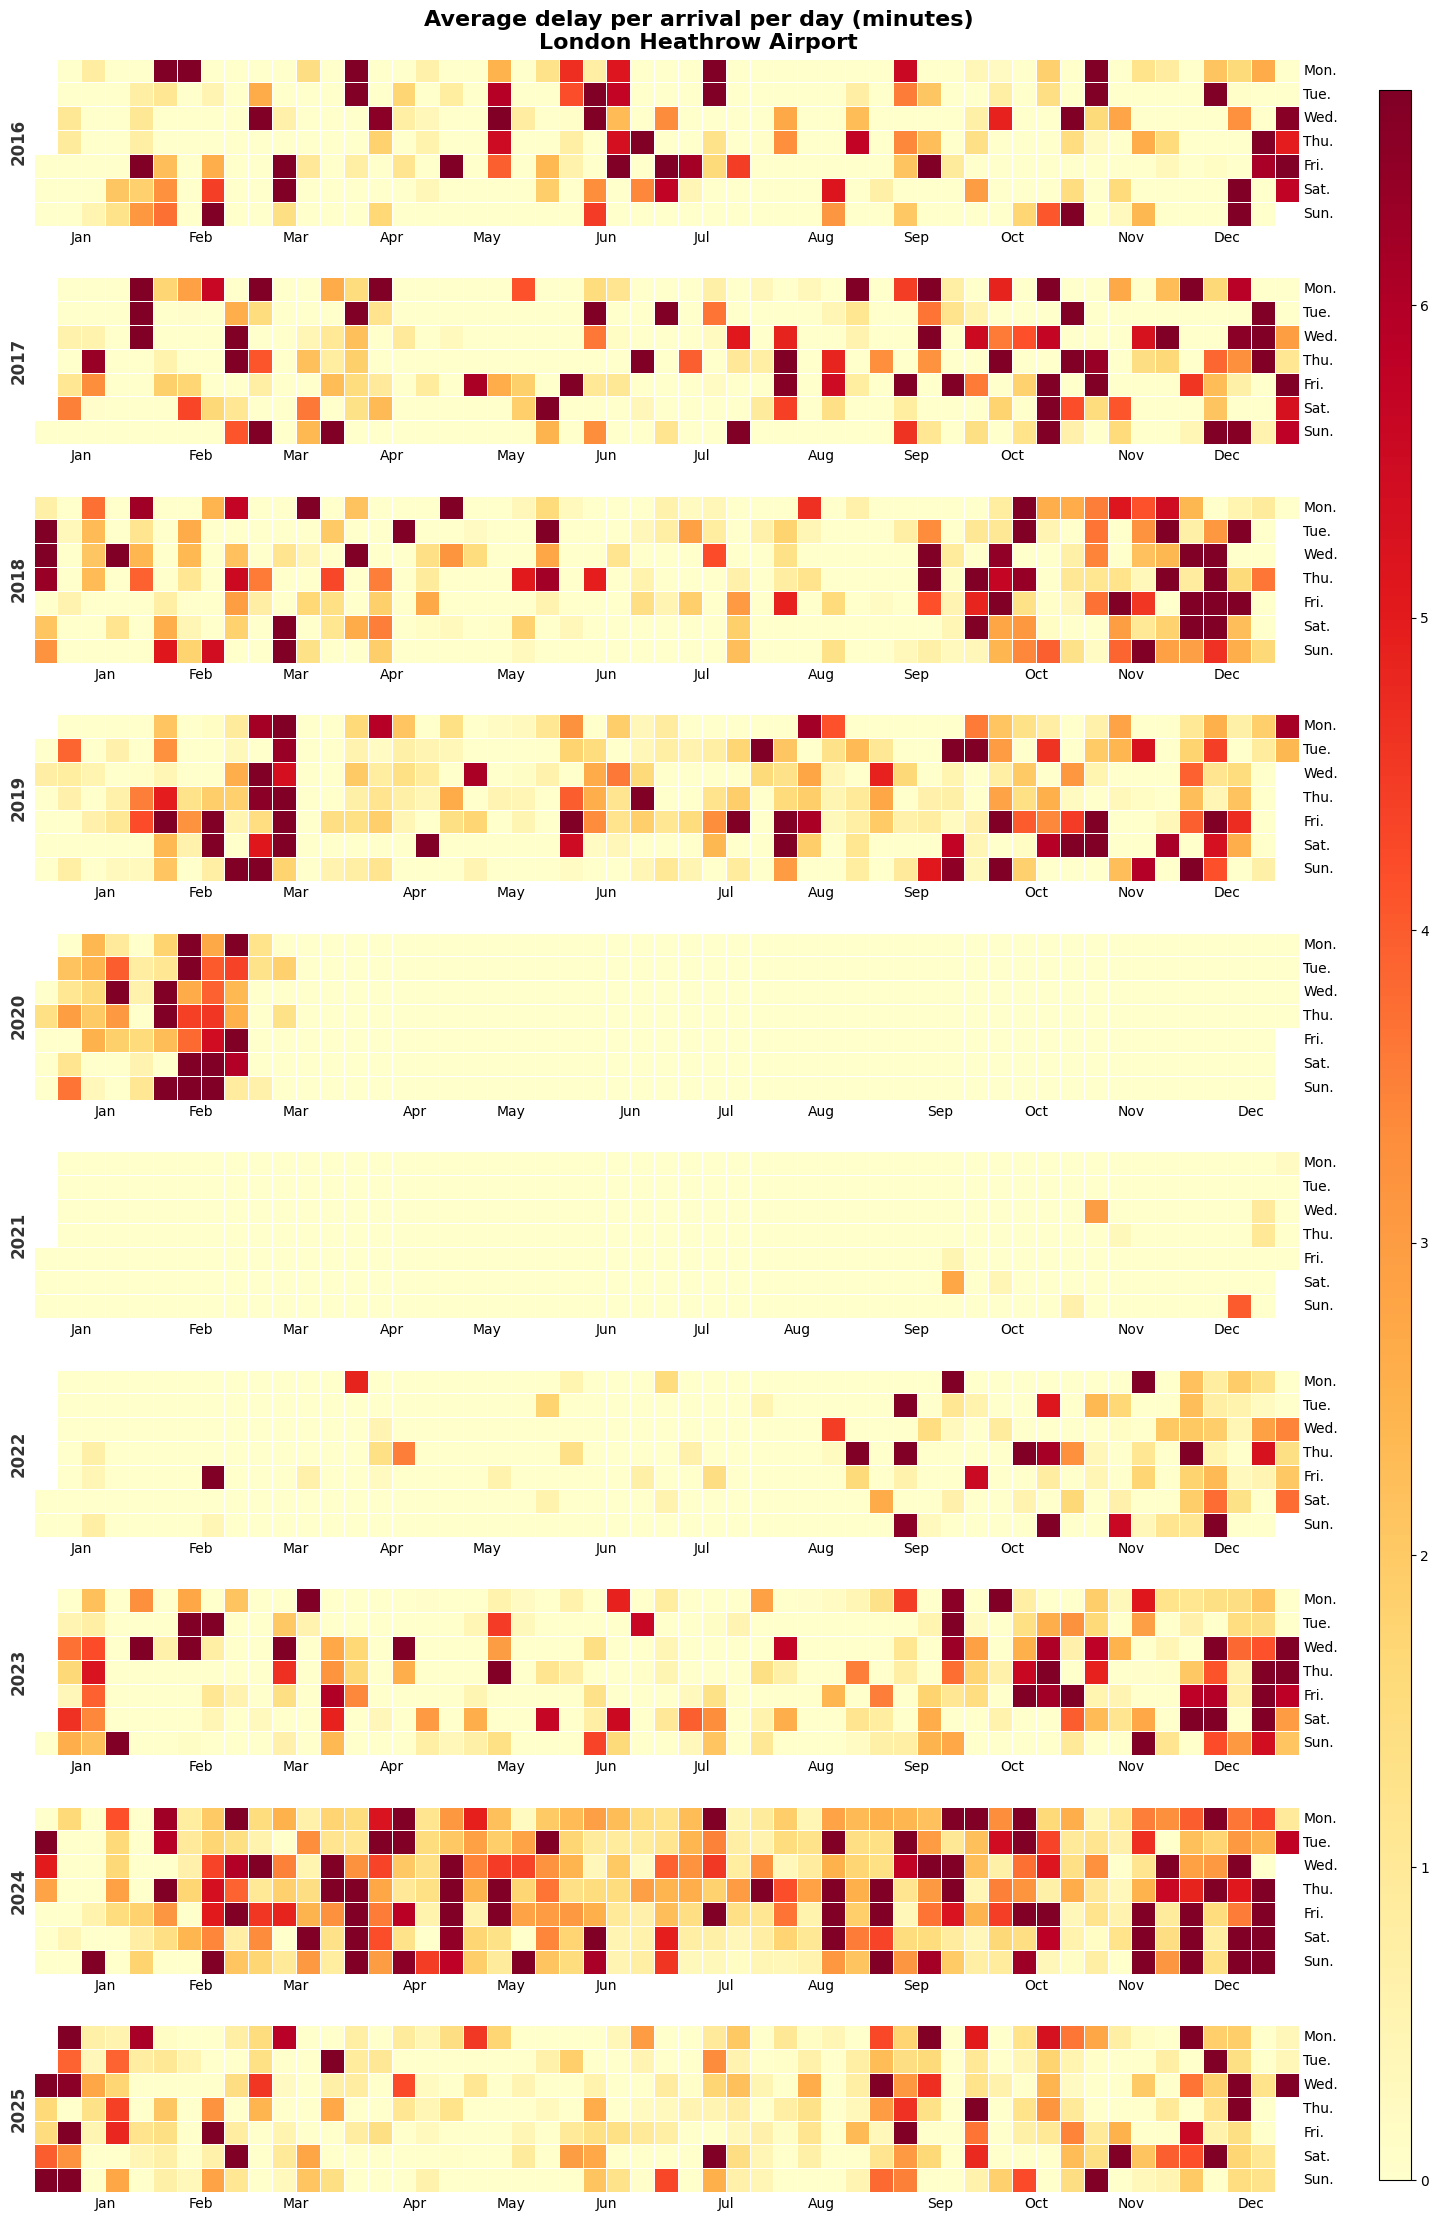

In [97]:
# -----------------------------------------------------------------
# 1. Prepare Data
# -----------------------------------------------------------------


dates_start = "2016-01-01"
dates_end = "2025-12-31"
apt_icao = 'EGLL'

query_heatmap = """
SELECT
    flt_date,
    ROUND(SUM(COALESCE(dly_apt_arr_1, 0)) / NULLIF(SUM(flt_arr_1), 0), 2) AS avg_delay_per_arrival
FROM fact_airport_delay
WHERE flt_date >= %s AND flt_date <= %s AND apt_icao = %s
GROUP BY flt_date
ORDER BY flt_date ASC;
"""

ts_df = pd.read_sql(query_heatmap, engine, params=(dates_start, dates_end, apt_icao))
ts = ts_df.set_index("flt_date")["avg_delay_per_arrival"]
ts.index = pd.to_datetime(ts.index)


# -----------------------------------------------------------------
# 2. Heatmap
# -----------------------------------------------------------------

# Get airport name
query_name = """
SELECT name
FROM dim_airport
WHERE ident = %s;
"""
result = pd.read_sql(query_name, engine, params=(apt_icao,))
airport_name = result["name"].iloc[0]

# calculate figure height and title offset (dynamic)
n_years = ts.index.year.nunique()
fig_height = 2.2 * n_years
title_offset_inches = 0.25
title_y = 1 + (title_offset_inches / fig_height)

# vmax only over days with actual delay (excludes 0-values from scale calculation)
# to avoid skewing the colormap when most days have 0 ATFM delay (e.g. EDDM ~82%)
vmax = ts[ts > 0].quantile(0.85)

# Plot Heatmap
fig, axes = calplot.calplot(
    ts,
    how=None,                 # data is already aggregated daily, no resampling needed
    dropzero=False,           # prevent calplot from auto-converting 0→NaN when >50% zeros
    cmap="YlOrRd",
    colorbar=True,
    suptitle=f"Average delay per arrival per day (minutes)\n{airport_name}",
    suptitle_kws={"fontsize": 16, "fontweight": "bold", "y": title_y},
    figsize=(16, fig_height),
    edgecolor="white",
    linewidth=0.6,
    fillcolor="lightgrey",    # lightgrey = missing data (no row in fact_airport_delay)
    vmin=0,
    vmax=vmax,
    yearlabel_kws={"fontsize": 12, "fontweight": "bold", "color": "#333333"},
    monthlabels=["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                  "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    daylabels=["Mon.", "Tue.", "Wed.", "Thu.", "Fri.", "Sat.", "Sun."],
)

plt.show()

##### Event Annotation:

| Date | Avg Delay (min) | Event | Category | Source |
|---|---|---|---|---|
| 2016-02-08 | 25.0 | Freezing fog across southern England – Heathrow cancelled ~100 flights | Weather – Fog | BBC News, February 2016 |
| 2016-12-17 | 48.1 | Freezing fog – British Airways cancelled 49 departing and 49 arriving flights at Heathrow | Weather – Fog | Associated Press / Fox News, December 2017 |
| 2016-12-30 | 60.3 | Post-Christmas winter disruption – snow and ice across UK | Weather – Snow/Ice | Fox News, December 2016 |
| 2018-11-27 | 26.7 | Autumn fog event – low visibility procedures reducing runway throughput | Weather – Fog | Gulf News, 2018 |
| 2022-12-11 | 32.5 | Winter ice/snow event – Heathrow imposed movement restrictions, British Airways reduced schedule | Weather – Snow/Ice | Simple Flying, December 2022 |
| 2024-11-24 | 29.6 | Autumn fog period Nov 2024 – consecutive disruption day | Weather – Fog | Bloomberg, December 2024 |
| 2024-12-27 | 30.8 | Post-Christmas fog – thick fog blanketed UK airports 27–29 Dec 2024 | Weather – Fog | Euronews, December 2024 |
| 2024-12-29 | 24.7 | Fog continues – Heathrow advised passengers to check flight status | Weather – Fog | The National, December 2024 |

**Overall trend:**  
EGLL shows fewer delay days than EHAM, but with more concentrated, episodic clusters. Notable: an unusually persistent delay period Oct–Dec 2018, and a dense Apr–Aug 2024 cluster not observed at EHAM.

**Seasonality:**  
Bi-modal pattern: summer peak (Jun–Aug) and a secondary autumn/winter peak (Oct–Dec), the latter likely driven by low visibility/fog events reducing runway throughput at Europe's most capacity-constrained two-runway airport.

**COVID impact:**  
2021 shows near-zero activity (sharper collapse than EHAM), reflecting Heathrow's higher dependency on long-haul international traffic. Recovery from 2022 is steeper than EHAM.

#### 3.3 EHAM vs. EGLL: Key Differences

| | EHAM | EGLL |
|---|---|---|
| Delay frequency | High: many days with measurable delay | Lower: delays concentrated in episodic clusters |
| Primary drivers | Wind/storms, capacity constraints | Fog/low visibility, structural runway capacity |
| Seasonality | Summer-dominated | Bi-modal (summer + autumn/winter) |
| Post-COVID trend | Exceeds pre-pandemic levels by 2024 | Dense summer cluster in 2024 |


**EHAM's** extreme days are dominated by weather events (storms/snow, ~70%) and labour disputes (2022, ~15%). A notable exception is the Apr–May 2019 cluster, caused by the multi-week rollout of a new Electronic Flight Strip system in Schiphol's ATC towers (IT infrastructure migration directly impacting network capacity).

**EGLL's** extreme days are almost exclusively weather-driven, with fog/low visibility as the primary cause (~80%) reflecting Heathrow's structural sensitivity to low-visibility conditions at 98% runway capacity, where even minor visibility reductions force wider aircraft spacing and cascade into significant ATFM delays.